In [1]:
# All of the imports
import torch
import os
from grn_inference_msc.vae_model.vae_model import Model, ModelConfig
from grn_inference_msc.vae_model.constants import ProbabilityDistributions
from grn_inference_msc.vae_model.data import Dataset
from utils import float_to_unique_string
from grn_inference_msc.vae_model.loss import BetaVAELoss
from tqdm import trange
from benchmark import stats_pipeline
import numpy as np
from grn_inference_msc.zscore_variant.inference import get_A_1
import matplotlib.pyplot as plt

In [2]:
# Params for the data used in this notebook
n_genes = 100
n_reps = 3
snr = 0.1

dataset_name = f'dataset_{n_genes}g_{n_reps}r_SNR{float_to_unique_string(snr)}_1'
val_dataset_name = f'dataset_{n_genes}g_{n_reps}r_SNR{float_to_unique_string(snr)}_2'
dataset = Dataset(os.path.join('../compare_methods/data', dataset_name))
val_dataset = Dataset(os.path.join('../compare_methods/data', val_dataset_name))
A_true = np.abs(np.sign(dataset.get_A().numpy()))

In [3]:
# Hyperparameters of the model:
dim_latent = 4
grn_layer_type = 'none'
encoder_hidden_dimensions = [128]
decoder_hidden_dimensions = [128]
beta = 1
lr = 0.001
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [4]:
config = ModelConfig(
    n_genes=n_genes,
    dim_in=n_genes*n_reps,
    dim_latent=dim_latent,
    likelihood_distribution=ProbabilityDistributions.GAUSSIAN,
    encoder_hidden_dimensions=encoder_hidden_dimensions,
    decoder_hidden_dimensions=decoder_hidden_dimensions,
    device=device,
    grn_layer_type=grn_layer_type
)

model = Model(config)

criterion = BetaVAELoss(beta)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [5]:
# Train the model to reconstruct the dataset
losses = []
AUROCs = []
val_losses = []

# Initial loss before any training
with torch.no_grad():
    model.eval()
    X, P = dataset.get_batch_normalized()

    mu, mu_latent, logvar_latent = model(X.to(device))
    loss = criterion(X.to(device), mu, mu_latent, logvar_latent)
    losses.append(loss.item())
    A_pred = get_A_1(model, X, P, device)
    _, AUROC, _ = stats_pipeline(A_pred, A_true)
    AUROCs.append(AUROC)


EPOCHS = trange(200, desc='Training model...')
for e in EPOCHS:
    model.train()
    optimizer.zero_grad()
    X, P = dataset.get_batch_normalized()

    mu, mu_latent, logvar_latent = model(X.to(device))

    loss = criterion(X.to(device), mu, mu_latent, logvar_latent)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    EPOCHS.set_postfix(loss=loss.item())

    A_pred = get_A_1(model, X, P, device)
    _, AUROC, _ = stats_pipeline(A_pred, A_true)
    AUROCs.append(AUROC)

    with torch.no_grad():
        model.eval()
        X_val, _ = val_dataset.get_batch_normalized()
        mu, mu_latent, logvar_latent = model(X_val.to(device))
        val_loss = criterion(X_val.to(device), mu, mu_latent, logvar_latent)
        val_losses.append(val_loss.item())

Training model...: 100%|██████████| 200/200 [00:16<00:00, 11.91it/s, loss=359]


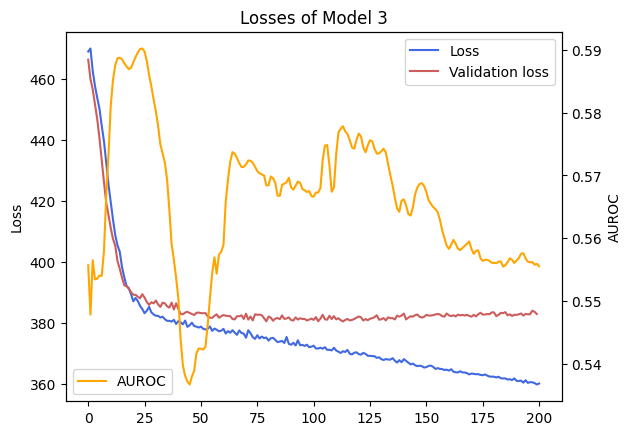

In [9]:
fig, ax = plt.subplots()

ax.set_title('Losses of Model 3')
ax.plot(losses, color='royalblue', label='Loss')
ax.plot(val_losses, color='indianred', label='Validation loss')
ax.set_ylabel('Loss')
plt.legend()
ax2 = ax.twinx()
ax2.plot(AUROCs, color='orange', label='AUROC')
ax2.set_ylabel('AUROC')

plt.legend(loc='lower left')
plt.xlabel('Epoch')

plt.show()

In [7]:
# Testing early stopping
from grn_inference_msc.vae_model.early_stopping import EarlyStopping

stopper = EarlyStopping(10, 2, model)

config = ModelConfig(
    n_genes=n_genes,
    dim_in=n_genes*n_reps,
    dim_latent=dim_latent,
    likelihood_distribution=ProbabilityDistributions.GAUSSIAN,
    encoder_hidden_dimensions=encoder_hidden_dimensions,
    decoder_hidden_dimensions=decoder_hidden_dimensions,
    device=device,
    grn_layer_type=grn_layer_type
)

model = Model(config)

criterion = BetaVAELoss(beta)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [ ]:
# Train the model to reconstruct the dataset
losses = []
AUROCs = []
val_losses = []

# Initial loss before any training
with torch.no_grad():
    model.eval()
    X, P = dataset.get_batch_normalized()

    mu, mu_latent, logvar_latent = model(X.to(device))
    loss = criterion(X.to(device), mu, mu_latent, logvar_latent)
    losses.append(loss.item())
    A_pred = get_A_1(model, X, P, device)
    _, AUROC, _ = stats_pipeline(A_pred, A_true)
    AUROCs.append(AUROC)


EPOCHS = trange(200, desc='Training model...')
for e in EPOCHS:
    model.train()
    optimizer.zero_grad()
    X, P = dataset.get_batch_normalized()

    mu, mu_latent, logvar_latent = model(X.to(device))

    loss = criterion(X.to(device), mu, mu_latent, logvar_latent)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    EPOCHS.set_postfix(loss=loss.item())

    A_pred = get_A_1(model, X, P, device)
    _, AUROC, _ = stats_pipeline(A_pred, A_true)
    AUROCs.append(AUROC)

    with torch.no_grad():
        model.eval()
        X_val, _ = val_dataset.get_batch_normalized()
        mu, mu_latent, logvar_latent = model(X_val.to(device))
        val_loss = criterion(X_val.to(device), mu, mu_latent, logvar_latent)
        val_losses.append(val_loss.item())

    if stopper.step(val_loss.item(), e):
        print (f'Stopped at epoch {e}, best epoch is {stopper.best_epoch}')
        break

Training model...:  20%|██        | 40/200 [00:03<00:15, 10.53it/s, loss=380]

Stopped at epoch {e}, best epoch is {stopper.best_epoch}
Stopped at epoch {e}, best epoch is {stopper.best_epoch}
Stopped at epoch {e}, best epoch is {stopper.best_epoch}


Training model...:  21%|██        | 42/200 [00:04<00:14, 10.92it/s, loss=379]

Stopped at epoch {e}, best epoch is {stopper.best_epoch}


Training model...:  26%|██▌       | 52/200 [00:05<00:15,  9.30it/s, loss=379]

...

Training model...:  98%|█████████▊| 197/200 [00:18<00:00, 11.88it/s, loss=360]

Stopped at epoch {e}, best epoch is {stopper.best_epoch}
Stopped at epoch {e}, best epoch is {stopper.best_epoch}
Stopped at epoch {e}, best epoch is {stopper.best_epoch}


Training model...: 100%|█████████▉| 199/200 [00:18<00:00, 12.59it/s, loss=360]

Stopped at epoch {e}, best epoch is {stopper.best_epoch}
Stopped at epoch {e}, best epoch is {stopper.best_epoch}
Stopped at epoch {e}, best epoch is {stopper.best_epoch}


Training model...: 100%|██████████| 200/200 [00:18<00:00, 10.54it/s, loss=360]
